# Exploratory Data Analysis

**Project: IndiaKart E-Commerce Analytics Project Exploratory Data Analysis**

# Objective: 
To explore the cleaned e-commerce datasets by analyzing their statistical properties, identifying patterns and relationships, visualizing key trends, and generating meaningful business insights to support informed decision-making.

# Import Libraries

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Monthly Order Volume: 
A bar chart showing number of orders per month for all 24 months. Highlight the Diwali months.

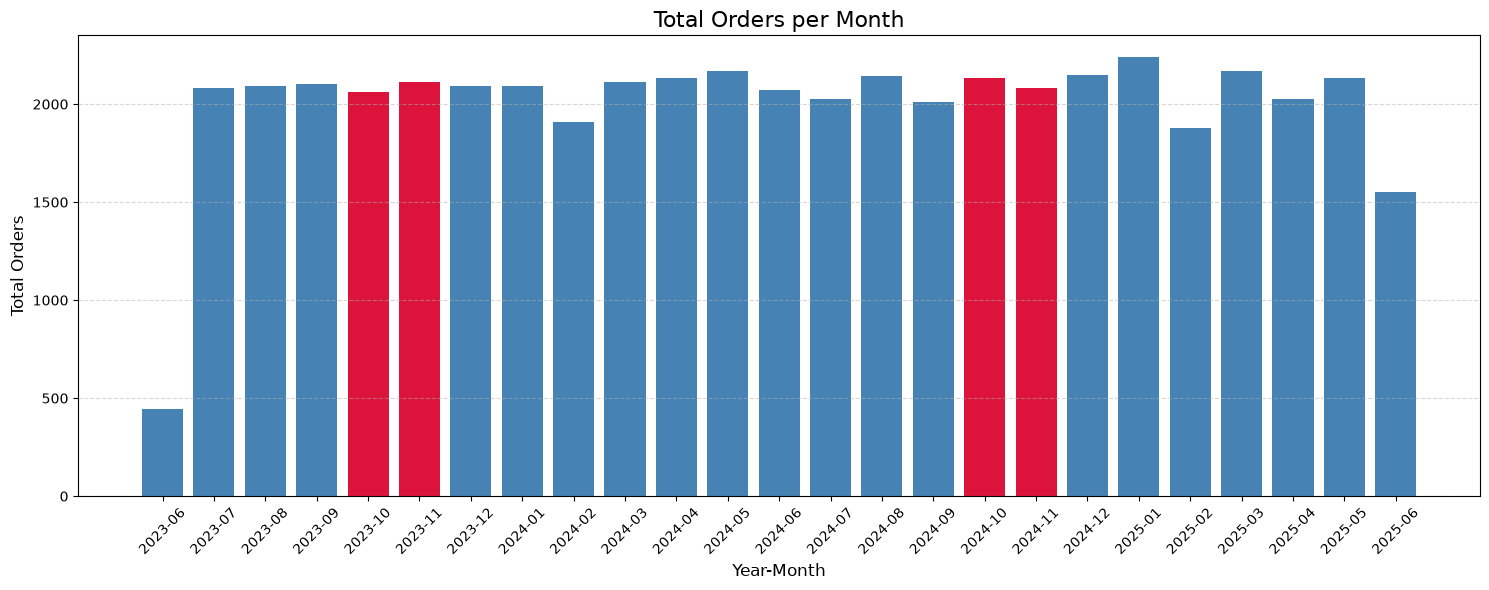

In [31]:
#read cleaned csv file for creating chart
orders_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_orders.csv")
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

#Create a Year-Month column for grouping
orders_df["Year-Month"] = orders_df["order_date"].dt.to_period("M")

monthly_orders = (orders_df.groupby("Year-Month").size().reset_index(name="total_orders"))

monthly_orders["Year-Month"] = monthly_orders["Year-Month"].astype(str)

#Create the Bar chart
colors = []
for month in monthly_orders["Year-Month"]:
    if month.endswith("-10") or month.endswith("-11"):
        colors.append("crimson") 
    else:
        colors.append("steelblue")

plt.figure(figsize=(15, 6))
plt.bar(monthly_orders["Year-Month"], monthly_orders["total_orders"], color=colors)
plt.title("Total Orders per Month", fontsize=16)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Monthly revenue (GMV):
A line Chart Showing final_amount per Month. Compare year-over-year.

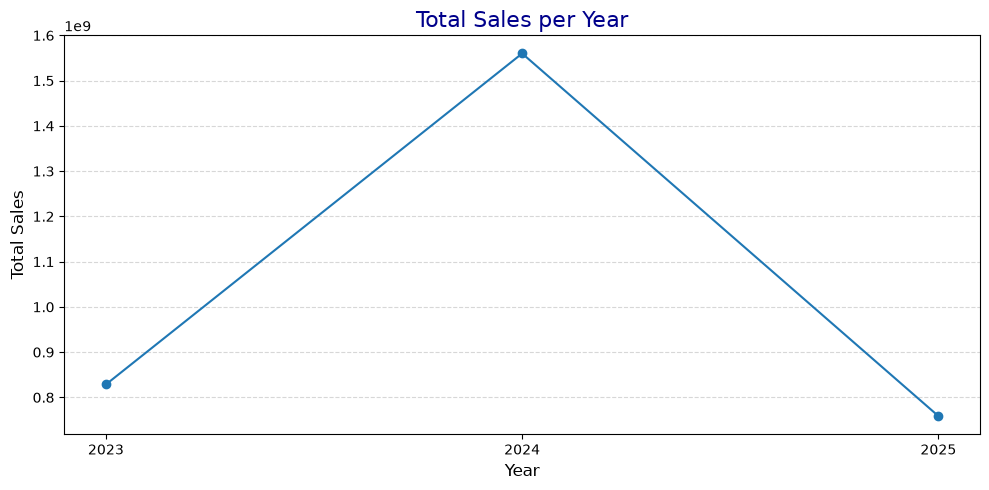

In [32]:
#read cleaned csv file for creating chart
orders_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_orders.csv")
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

#Group by year to get final_amount per year
orders_df["Year"] = orders_df["order_date"].dt.year
yearly_amount = orders_df.groupby("Year")["final_amount"].sum().reset_index()
yearly_amount["Year"] = yearly_amount["Year"].astype(str)

#Create the Line chart
plt.figure(figsize=(10, 5))
plt.plot(yearly_amount["Year"], yearly_amount["final_amount"], marker="o", linestyle="-")
plt.title("Total Sales per Year", fontsize=16, color="darkblue")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Category-wise revenue share: 
A Pie Chart showing which category earns the most.

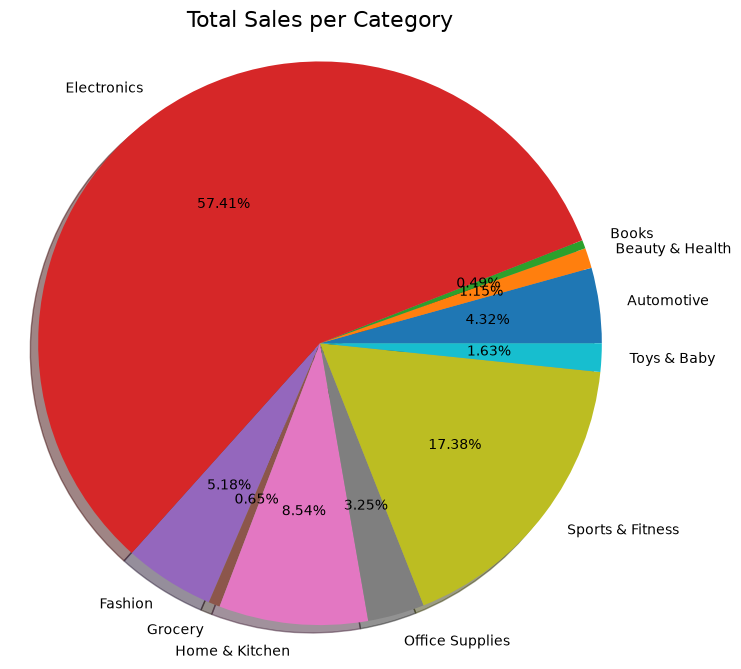

In [33]:
#read cleaned csv file for creating chart
order_items_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_order_items.csv")
order_items_df.head()

#Group by category to get total amount per category
category_amount = order_items_df.groupby("category")["total_price"].sum().reset_index()
category_amount["category"] = category_amount["category"].astype(str)

#Pie chart for total amount per category
plt.figure(figsize=(8, 8))
plt.pie(category_amount["total_price"], labels=category_amount["category"], autopct='%1.2f%%', shadow=True)
plt.title("Total Sales per Category", fontsize=16,)
plt.axis("equal")  
plt.show()

# Order status distribution: 
A Donut Chart showing % of Delivered, Cancelled, Returned, Shipped, Processing.

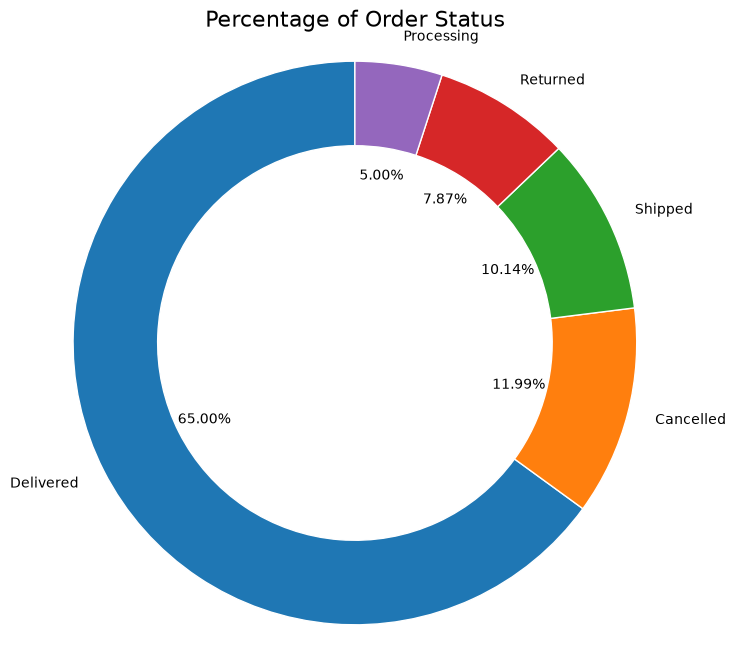

In [34]:
#read cleaned csv file for creating chart
orders_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_orders.csv")

#Group by status to get percentage of status
status_count = orders_df["status"].value_counts(normalize=True) * 100

#Donut Chart showing % of status
plt.figure(figsize=(8, 8))
plt.pie(status_count, labels=status_count.index, autopct='%1.2f%%', startangle=90, wedgeprops={'width': 0.3, 'edgecolor': 'w'})
plt.title("Percentage of Order Status", fontsize=16)
plt.axis("equal")
plt.show()

# Top 10 states by number of orders: 
A horizontal bar chart showing top 10 states by number of orders.

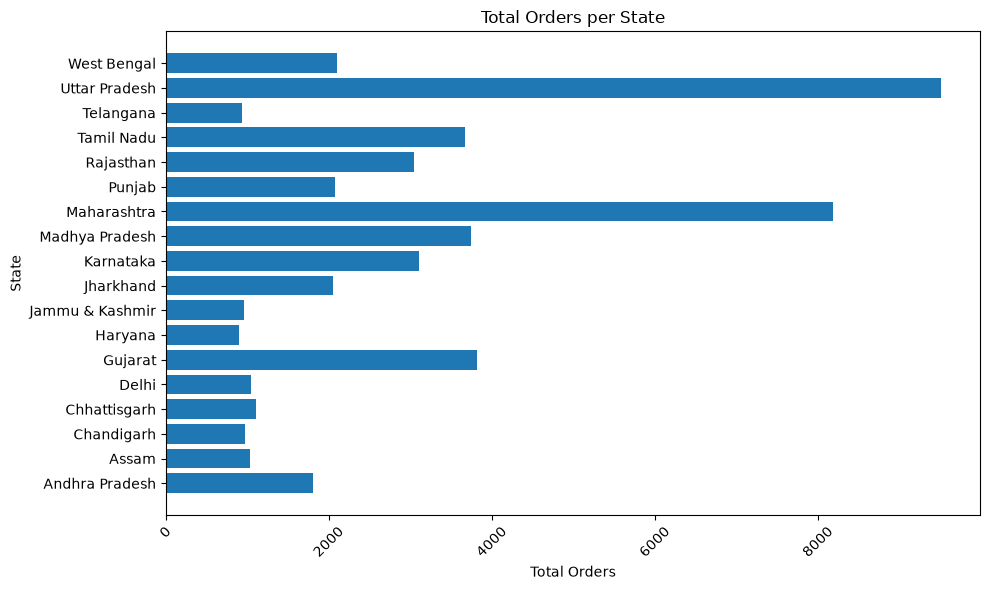

In [35]:
#read cleaned csv file for creating chart
orders_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_orders.csv")

#group by states to get total orders per state
state_counts = orders_df.groupby("state").size()

#horizontal bar chart for total orders per state
plt.figure(figsize=(10, 6))
plt.barh(state_counts.index, state_counts.values)
plt.xlabel("Total Orders")
plt.ylabel("State")
plt.title("Total Orders per State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Customer segment distribution: 
A Pie Chart showing total number of customers for Premium vs. Regular vs. Budget.

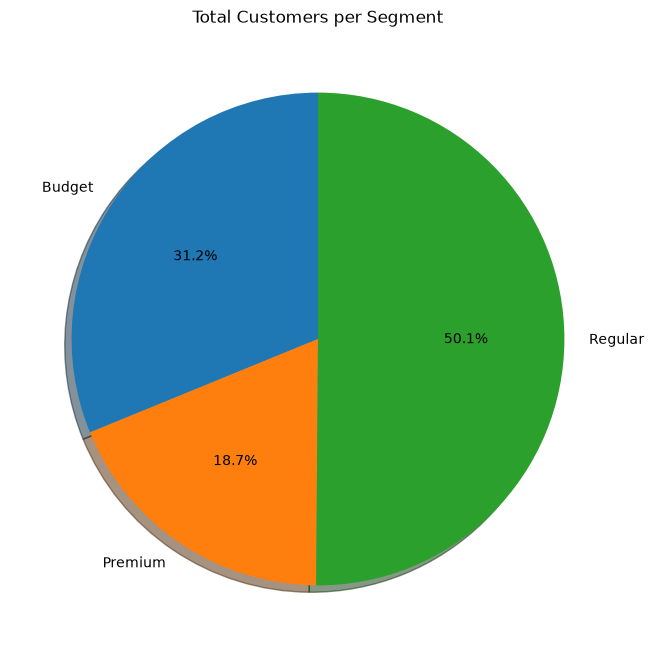

In [36]:
#read cleaned csv file for creating chart
customers_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_customers.csv")

#group by segments to get total customers per segment
customers_df = customers_df[customers_df["segment"].isin(["Premium", "Budget", "Regular"])]
segment_counts = customers_df.groupby("segment").size()

#Pie chart for total customers per segment
plt.figure(figsize=(8, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Total Customers per Segment')
plt.show()

# Payment method usage:
A Bar chart showing which methods are most popular

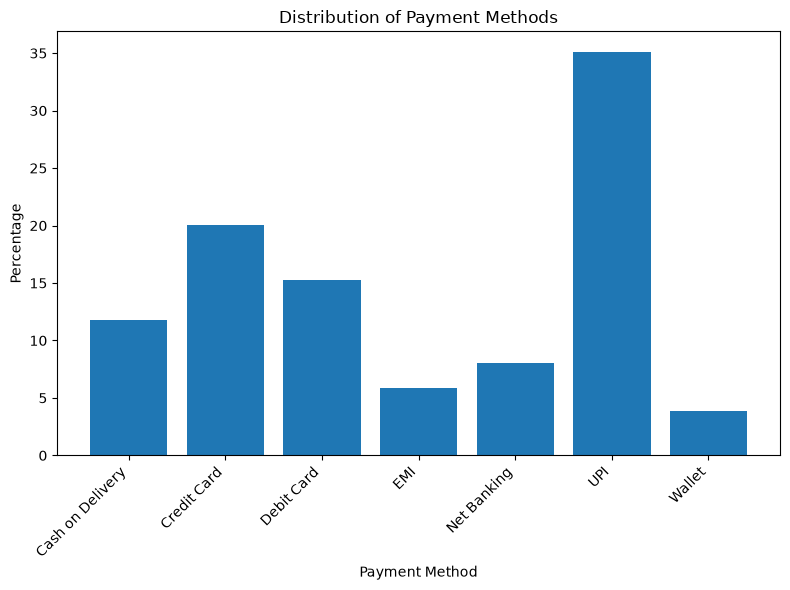

In [37]:
#read cleaned csv file for creating chart
orders_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_orders.csv")

#group by payment method to get percentage of payment methods
orders_df = orders_df.groupby("payment_method").size().reset_index(name="count")
orders_df["percentage"] = (orders_df["count"] / orders_df["count"].sum()) * 100

#bar chart for percentage of payment methods
plt.figure(figsize=(8, 6))
plt.bar(orders_df["payment_method"], orders_df["percentage"])
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.title("Distribution of Payment Methods")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Age distribution of customers: 
A histogram showing percentage of age group shops most.

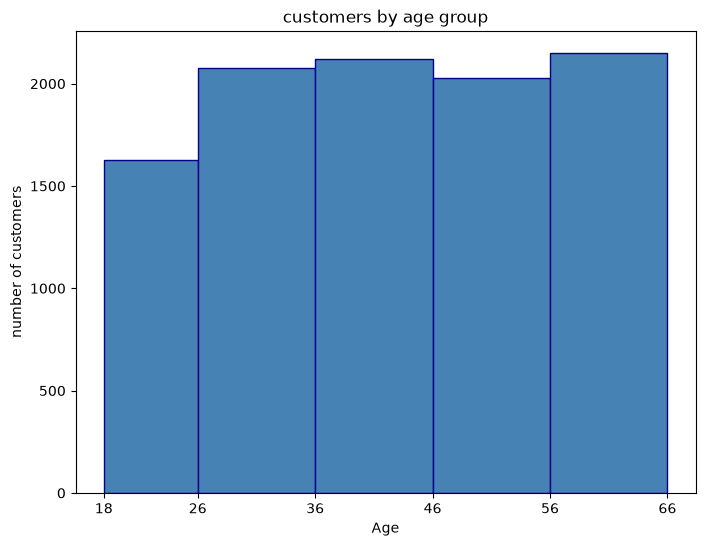

In [38]:
#read cleaned csv file for creating chart
customers_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_customers.csv")

#histogram showing age group shop most
plt.figure(figsize=(8, 6))
plt.hist(customers_df['age'], bins=[18, 26, 36, 46, 56,66], color='steelblue', edgecolor='darkblue')
plt.xlabel('Age')
plt.ylabel('number of customers')
plt.title('customers by age group')
plt.xticks([18, 26, 36, 46, 56, 66])
plt.show()

# Return reasons: 
A Bar Chart showing the most common return reasons.

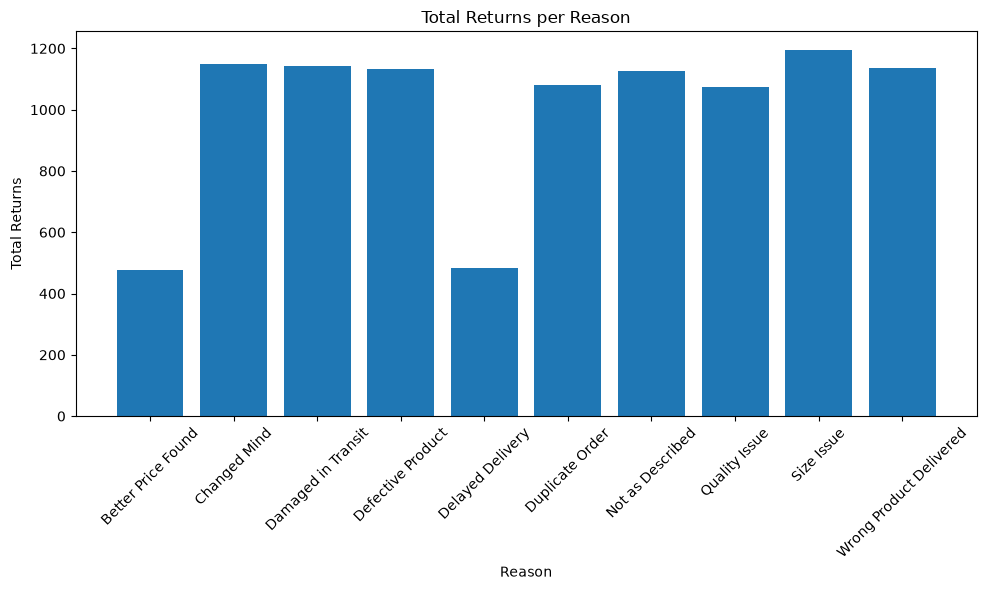

In [39]:
#read cleaned csv file for creating chart
returns_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_returns.csv")

#group by reason to get total returns per reason
reason_counts = returns_df.groupby("reason").size()

#bar chart for total returns per reason
plt.figure(figsize=(10, 6))
plt.bar(reason_counts.index, reason_counts.values)
plt.xlabel("Reason")
plt.ylabel("Total Returns")
plt.title("Total Returns per Reason")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Average Order Value (AOV) by segment:
A bar chart showing if Premium customers spend more per order.

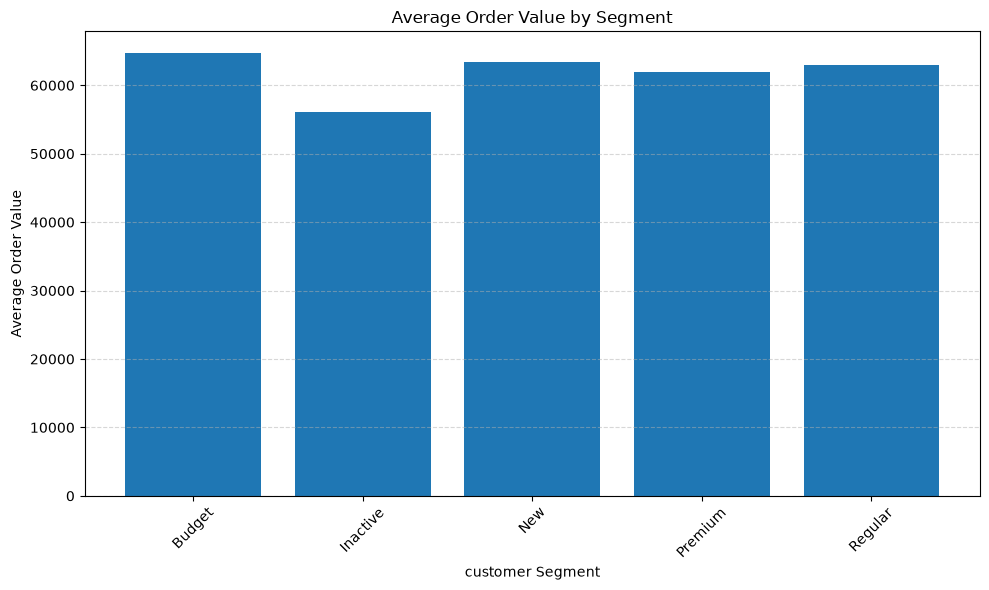

In [40]:
#read cleaned csv file for creating chart
customers_df = pd.read_csv("../Phase1_DataCleaning_[Anisha Azmi]/Cleaned_Data/cleaned_customers.csv")

#calculate AOV (Average Order Value) for each customer
customers_df["AOV"] = customers_df["total_spent"] / customers_df["total_orders"]
customers_df = customers_df[customers_df["total_orders"] > 0]
segment_AOV = customers_df.groupby("segment")["AOV"].mean().reset_index()

#bar chart for AOV
plt.figure(figsize=(10, 6))
plt.bar(segment_AOV["segment"], segment_AOV["AOV"])
plt.xlabel("customer Segment")
plt.ylabel("Average Order Value")
plt.title("Average Order Value by Segment")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()